In [1]:
import os
for root,dirs,files in os.walk('/workspace'):
 if root.count(os.sep)>3: dirs[:]=[]; continue
 print(root,[(f,round(os.path.getsize(os.path.join(root,f))/1024,1)) for f in files[:30]])

/workspace [('README_EDISON.md', 3.3), ('.kernel_llm_logs_1.txt', 0.0)]
/workspace/docs [('powder-property-correlations.md', 12.1), ('powder-battery-protocol.md', 39.5)]
/workspace/docs/battery-runs [('2026-08-21-alsi10mg.md', 13.6), ('2026-08-20-salt-artifact-rejection.md', 5.3), ('2026-08-21-fumed-silica.md', 10.8), ('2026-08-21-salt-control-repeat.md', 10.6), ('2026-08-20-silicon-110-200.md', 10.4), ('2026-08-21-silicon-325.md', 7.9), ('run-log.csv', 18.6), ('RUN-LOG.md', 53.3), ('2026-08-12-salt-repeat.md', 7.5)]
/workspace/.prompts [('USER.md', 0.7), ('BOOTSTRAP.md', 5.5), ('MEMORY.md', 0.4)]
/workspace/memory [('0b0b98aa-d9f8-485f-9c1c-e403197a2b04_memory_heron_c0_20261007T062054049514.jsonl', 19.2)]
/workspace/data []
/workspace/data/opt []
/workspace/data/powder-properties [('battery_responses.csv', 2.4), ('literature_powder_properties.csv', 1.3), ('literature_powder_properties_long.csv', 21.3), ('correlation_table.md', 3.5)]
/workspace/data/battery []
/workspace/.config []
/wo

In [2]:
import glob,pandas as pd, json,numpy as np
for pattern in ['/workspace/data/battery/*','/workspace/data/opt/*']:
 a=glob.glob(pattern);print(pattern,len(a),[(os.path.basename(x),len(glob.glob(x+'/**/*',recursive=True))) for x in a[:30]])
for p in ['/workspace/docs/battery-runs/run-log.csv','/workspace/data/powder-properties/battery_responses.csv','/workspace/data/powder-properties/literature_powder_properties.csv']:
 d=pd.read_csv(p);print('\n',p,d.shape,list(d.columns));print(d.head(3).to_string(index=False)[:2400])

/workspace/data/battery/* 37 [('20260909T185352Z_sodium-alginate', 6), ('20260805T200002Z_calcium-lactate', 6), ('20260910T194447Z_alsi10mg', 6), ('20260811T183043Z_alsi10mg', 6), ('20260805T211216Z_carboxymethyl-cellulose_preflight', 1), ('20260910T212920Z_silicon-325', 6), ('20260908T172730Z_carboxymethyl-cellulose', 6), ('20260804T224937Z_brown-rice-flour', 5), ('20260821T192031Z_salt', 7), ('20260904T001821Z_salt', 6), ('20260909T225206Z_calcium-lactate', 7), ('20260821T182705Z_fumed-silica', 8), ('20260915T025556Z_silicon-110-200', 7), ('20260806T140254Z_xanthan-gum', 6), ('20260821T170712Z_barium-chloride', 6), ('20260805T185305Z_brown-rice-flour', 6), ('20260910T170858Z_barium-chloride', 7), ('20260821T151337Z_alsi10mg', 7), ('20260820T175631Z_salt', 8), ('20260806T145120Z_salt', 6), ('20260903T163527Z_salt', 6), ('20260820T214823Z_silicon-110-200', 7), ('20260812T215154Z_salt', 6), ('20260804T211422Z_white-rice-flour', 5), ('20260910T231950Z_silicon-110-200_preflight', 1), ('20

In [3]:
log=pd.read_csv('/workspace/docs/battery-runs/run-log.csv');print(log[['started_utc','powder_id','qc_valid','qc_verdict','feed_mg_per_rev_0','feed_mg_per_rev_45','feed_mg_per_rev_90','data_dir']].to_string(index=False));print('\nexample files:',glob.glob('/workspace/data/battery/20260821T192031Z_salt/*'));print('\nopt:',glob.glob('/workspace/data/opt/*/**/*',recursive=True)[:30]);print('\nproperties');print(pd.read_csv('/workspace/data/powder-properties/battery_responses.csv').to_string(index=False))

                     started_utc               powder_id  qc_valid                             qc_verdict  feed_mg_per_rev_0  feed_mg_per_rev_45  feed_mg_per_rev_90                                                        data_dir
2026-08-04T20:43:16.183255+00:00        brown-rice-flour     False            no-conveyance-auger-suspect               0.22                0.20                0.10                  data/battery/20260804T204316Z_brown-rice-flour
2026-08-04T21:14:22.351081+00:00        white-rice-flour      True                                     ok               3.75               12.78               37.15                  data/battery/20260804T211422Z_white-rice-flour
2026-08-04T22:49:37.985918+00:00        brown-rice-flour     False            no-conveyance-auger-suspect               0.00                0.00                0.00                  data/battery/20260804T224937Z_brown-rice-flour
2026-08-05T14:57:25.298344+00:00         sodium-alginate      True                  

In [4]:
for p in glob.glob('/workspace/data/battery/20260821T192031Z_salt/*'):
 print(os.path.basename(p));
 if p.endswith('.csv'):
  d=pd.read_csv(p);print(d.shape,list(d.columns));print(d.head(2).to_string(index=False)[:500])
print('\nvalid counts',log.groupby(['powder_id','qc_valid']).size().to_string());print('opt trial examples')
for p in glob.glob('/workspace/data/opt/*/zero/trial_*.json')[:3]:
 j=json.load(open(p));print(p,j.keys());print(str(j)[:1000])

timeline_salt.csv
(5, 5) ['powder_id', 'block', 'started_utc', 'started_local', 'elapsed_s']
powder_id block                      started_utc           started_local  elapsed_s
     salt     A 2026-08-21T19:20:33.590064+00:00 2026-08-21 13:20:33 MDT        2.4
     salt     B 2026-08-21T19:21:19.318041+00:00 2026-08-21 13:21:19 MDT       48.1
retries_salt.csv
(10, 9) ['powder_id', 'block', 'tilt_deg', 'phase', 'trial', 'reason', 'shock_g', 'discarded_delta_g', 't_ms']
powder_id block  tilt_deg  phase  trial reason  shock_g  discarded_delta_g   t_ms
     salt     E       0.0 refeed      3  shock  -0.0369             0.0437 513501
     salt     E       0.0 refeed      3  shock  -0.0139             0.0430 525073
summary_salt.csv
(12, 11) ['powder_id', 'block', 'tilt_deg', 'phase', 'n', 'mean_g', 'std_g', 'sem_g', 'min_g', 'max_g', 'rsd_pct']
powder_id block  tilt_deg    phase  n   mean_g    std_g    sem_g   min_g  max_g    rsd_pct
     salt     A      45.0 baseline  8 0.001313 0.002882 0.

In [5]:
for _,r in log[log.qc_valid].iterrows():
 p='/workspace/'+str(r.data_dir);fl=glob.glob(p+'/trials_*.csv');
 if not fl:continue
 d=pd.read_csv(fl[0]);print(os.path.basename(p),str(r.blocks),d.groupby(['block','phase']).size().to_dict())
print('\nC salt sample'); print(pd.read_csv(glob.glob('/workspace/data/battery/20260821T192031Z_salt/trials*')[0]).query('block == "C"').to_string(index=False)[:3000]);
print('\nD sample');print(pd.read_csv(glob.glob('/workspace/data/battery/20260821T192031Z_salt/trials*')[0]).query('block == "D"').to_string(index=False)[:2400])

20260804T211422Z_white-rice-flour ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260805T145725Z_sodium-alginate ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260805T185305Z_brown-rice-flour ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260805T200002Z_calcium-lactate ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260805T215252Z_carboxymethyl-cellulose ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260806T140254Z_xanthan-gum ABCDEG {('A', 'baseline'): 8, ('B', 'hold'): 3, ('C', 'rotation'): 18, ('D', 'speed'): 3, ('E', 'refeed'): 16, ('E', 'tap'): 16}
20260806T145120Z_salt 

In [6]:
for p in glob.glob('/workspace/data/opt/production-*/zero/trial_*.json'):
 j=json.load(open(p));print(os.path.basename(os.path.dirname(os.path.dirname(p))),os.path.basename(p),j.get('trial_index'),j['parameters_executed'],j['outcomes'],j['telemetry'].keys(),j['telemetry']['header'],len(j['telemetry']['rows']));print('first',j['telemetry']['rows'][:2],'last',j['telemetry']['rows'][-2:]);print('stops',str(j['stop_events'])[:300])
print('salt campaign count',len(glob.glob('/workspace/data/opt/salt*/zero/trial_*.json')))

production-alsi10mg trial_64714f7c-c9ed-4ebe-887f-87a7e9bc16b0.json -1 {'tap_cadence_off_ms': 440, 'trickle_tap': False, 'trickle_tilt_deg': 10.0, 'tolerance_g': 0.003, 'goal_mass_g': 0.75, 'trickle_start_remaining_g': 0.3, 'bulk_tilt_deg': 40.0, 'tau_afterflow_s': 0.8338, 'tap_tilt_deg': 15.0, 'bulk_tap': True, 'overshoot_abort_g': 0.1, 'final_settle_ms': 2000, 'bulk_rpm': 100.0, 'tap_cadence_on_ms': 60} {'t_bulk_s': 56.61, 't_trickle_s': 11.39, 't_tap_s': 237.06, 't_settle_s': 3.24, 't_total_s': 314.54, 'settled_final_g': 7.99277, 'settled_final': True, 'error_mg': -7.23, 'abs_error_mg': 7.23, 'overshoot': False, 'taps': 182, 'nudges': 1, 'auger_rev': 87.075, 'ff_g_per_rev': 0.2689} dict_keys(['header', 'rows']) t_s,phase,z_g,fresh,m_g,r_gps,sigma_g,ff_gpr,r_sp_gps,err_gps,integ,rpm_cmd,pred_g,cutoff_g,clamp_hits 239
first ['7.93,bulk,-0.00113,1,-0.00113,,,,,,,,,,', '8.32,bulk,-0.00133,1,-0.00133,,,,,,,,,,'] last ['308.33,tap,7.99545,1,7.99545,,,,,,,,,,', '311.28,tap,7.99759,1,7.9975

In [7]:
for p in glob.glob('/workspace/data/opt/production-*/*'):
 if 'README' in p: print(p,open(p).read()[:5000])
print('\nsalt run raw')
for p in glob.glob('/workspace/data/opt/salt*/zero/trial*json')[:2]:
 j=json.load(open(p));print(j['trial_index'],j['parameters_executed'], j['telemetry']['header'],len(j['telemetry']['rows']),j['telemetry']['rows'][:3],j['stop_events'][:1])

/workspace/data/opt/production-alsi10mg/README.md # AlSi10Mg production doses

## 2026-09-29: first AlSi10Mg dose, 8 g target (trial `64714f7c`)

@sgbaird requested this dose in PR #166 after loading AlSi10Mg into the hopper. It used the
parameters recommended by the salt campaign
[`salt-20260929T014732Z`](../salt-20260929T014732Z/report.md), point `bo-005`. Those were tuned
for salt at a 0.5 g target and haven't been validated on this powder.

| | |
|---|---|
| searched parameters | bulk taps 2 Hz, trim taps off, bulk tilt 40°, trickle tilt 10°, tap tilt 15°, bulk 100 rpm, bulk→trim threshold 0.30 g, tolerance 3 mg, τ_afterflow 0.8338 s (salt fit) |
| everything else | the salt campaign's frozen `trickle_params.py` snapshot, with `log_to_flash 0` (the Pico's flash is nearly full) |
| result | **7.9928 g** at the 2 s scoring read (−7.2 mg, −0.09 %), status `ok`, 314.5 s |
| phases | bulk 56.6 s, trickle 11.4 s, taps 237.1 s (78 cycles; 182 taps including the bulk cadence taps; 1 auger 

In [8]:
from scipy import stats, optimize, signal
from pathlib import Path
out=Path('/workspace/analysis');out.mkdir(exist_ok=True)
valid=log[(log.qc_valid==True)&log.blocks.fillna('').str.contains('A')].copy();records=[];polls=[]
for _,r in valid.iterrows():
 base=Path('/workspace')/r.data_dir; tf=list(base.glob('trials_*.csv'));pf=list(base.glob('polls_*.csv'))
 if not tf:continue
 d=pd.read_csv(tf[0]);d['run']=base.name;d['powder']=r.powder_id;d['date']=r.started_utc[:10];records.append(d)
 if pf:
  p=pd.read_csv(pf[0]);p['run']=base.name;p['powder']=r.powder_id;polls.append(p)
t=pd.concat(records,ignore_index=True);pol=pd.concat(polls,ignore_index=True)
A=t.query('block=="A"');C=t.query('block=="C"');D=t.query('block=="D"');B=t.query('block=="B"');E=t.query('block=="E"');
print('A',A.shape,'C',C.shape,'D',D.shape,'pol D',pol.query('block=="D"').shape)
print('A metrics',A[['delta_g','sigma_g','drift_g','shock_g']].describe(percentiles=[.5,.9,.95]).round(4).to_string());print('nonzero shocks',t.groupby('block').shock_g.apply(lambda s:(s.fillna(0)!=0).sum()).to_string(), 'retries',t.groupby('block').retries.sum().to_string())
cs=C.groupby(['run','powder','tilt_deg']).delta_g.agg(['mean','std','count']).reset_index();cs['cv']=cs['std']/cs['mean'];print('\nC summary valid >noise mean > 0.01 g');print(cs.groupby('tilt_deg').cv.agg(['median','mean','min','max','count']).to_string()); print('\nsalt',cs.query('powder=="salt"').to_string(index=False))
print('\nqual',C.quality.value_counts());print('pol D',pol.query('block=="D"').groupby(['run','rpm']).size().describe())

A (112, 20) C (252, 20) D (42, 20) pol D (1008, 9)
A metrics         delta_g  sigma_g  drift_g  shock_g
count  112.0000  48.0000  48.0000  48.0000
mean     0.0004   0.0038  -0.0009   0.0005
std      0.0110   0.0038   0.0129   0.0057
min     -0.0481   0.0000  -0.0357  -0.0177
50%      0.0000   0.0034   0.0000   0.0000
90%      0.0022   0.0092   0.0112   0.0104
95%      0.0161   0.0094   0.0263   0.0112
max      0.0420   0.0111   0.0358   0.0145
nonzero shocks block
A    17
B     9
C     2
D     2
E     4 retries block
A     0.0
B     0.0
C    17.0
D     0.0
E    46.0

C summary valid >noise mean > 0.01 g
            median      mean       min       max  count
tilt_deg                                               
0.0       0.303875  0.430972  0.086151  1.763834     13
45.0      0.134584  0.312939  0.022431  2.259203     13
90.0      0.171092  0.598383  0.028909  2.449490     14

salt                   run powder  tilt_deg     mean      std  count       cv
20260806T145120Z_salt   salt  

In [9]:
print('A by run');print(A.groupby('run').agg(n=('delta_g','size'),sdelta=('delta_g','std'),med_sigma=('sigma_g','median'),med_absdrift=('drift_g',lambda x:x.abs().median()),shock_rate=('shock_g',lambda x:(x.fillna(0)!=0).mean())).round(4).to_string());print('C shocks:');print(C[C.quality=='shock'][['powder','run','tilt_deg','trial','delta_g','shock_g','retries']].to_string(index=False));print('D polls example:');print(pol.query('block=="D" and powder=="salt"').head(24).to_string(index=False))

A by run
                                          n  sdelta  med_sigma  med_absdrift  shock_rate
run                                                                                     
20260804T211422Z_white-rice-flour         8  0.0000        NaN           NaN       0.000
20260805T145725Z_sodium-alginate          8  0.0000        NaN           NaN       0.000
20260805T185305Z_brown-rice-flour         8  0.0000        NaN           NaN       0.000
20260805T200002Z_calcium-lactate          8  0.0000        NaN           NaN       0.000
20260805T215252Z_carboxymethyl-cellulose  8  0.0000        NaN           NaN       0.000
20260806T140254Z_xanthan-gum              8  0.0000        NaN           NaN       0.000
20260806T145120Z_salt                     8  0.0000        NaN           NaN       0.000
20260812T215154Z_salt                     8  0.0000        NaN           NaN       0.000
20260820T192224Z_sodium-sulfate           8  0.0243     0.0080        0.0106       0.625
20260820T214

/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/app/kernel_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
 

In [10]:
ss=[]
for p in glob.glob('/workspace/data/opt/salt*/zero/trial_*.json'):
 j=json.load(open(p));x=j.get('parameters_executed') or {};ss.append({'idx':j['trial_index'],'tilt':x.get('bulk_tilt_deg'),'rpm':x.get('bulk_rpm'),'tap':x.get('bulk_tap'),'time':j['outcomes'].get('t_bulk_s'),'n':len(j['telemetry']['rows']),'stop':j['stop_events'][0] if j['stop_events'] else None,'p':p})
sdf=pd.DataFrame(ss).sort_values('idx');print(sdf[['idx','tilt','rpm','tap','time','n']].to_string(index=False));print('counts same settings',sdf.groupby(['tilt','rpm','tap'],dropna=False).size().sort_values(ascending=False).head(20).to_string())

 idx    tilt      rpm   tap  time   n
   0 30.0000  55.0000 False  5.85 130
   1 40.0000  20.0000  True 11.66  22
   2 40.0000  20.0000 False  6.71  92
   3 15.0000  20.0000  True  8.51  56
   4 15.0000  20.0000 False 12.43 104
   5 15.0000 100.0000  True  7.07  11
   6 40.0000  20.0000 False  6.71  43
   7 15.0000  20.0000 False 13.48  70
   8 40.0000 100.0000  True  5.73  18
   9 40.0000 100.0000 False  6.41  12
  10 40.0000  20.0000  True 11.18  34
  11 15.0000 100.0000 False  5.37 129
  12 15.0000 100.0000  True  7.36  12
  13 40.0000 100.0000  True  5.55  59
  14 40.0000 100.0000 False  7.94  13
  15 15.0000 100.0000 False  6.30  69
  16 15.0000  20.0000  True  8.71 155
  17 27.5000  60.0000 False  8.12  55
  18 27.5000  60.0000 False  7.30 141
  19 27.5000  60.0000 False  7.66  38
  20 27.5000  60.0000 False  6.70 134
  21 30.0000  55.0000 False  7.56 114
  22 30.0000  55.0000 False  7.19  85
  23 27.5000  60.0000 False  7.46 143
  24 27.5000  60.0000 False  7.27 143
  25 27.5000

In [11]:
p=glob.glob('/workspace/data/opt/production-al4047*/zero/serial*log');print([(os.path.basename(x),os.path.getsize(x)) for x in p]);
for x in p[:3]:
 with open(x,errors='replace') as f: print(os.path.basename(x),f.read(1100))
print('D age',D[['powder','rpm','delta_g']].head())

[]
D age               powder   rpm  delta_g
29  white-rice-flour  15.0   0.0572
30  white-rice-flour  45.0   0.0723
31  white-rice-flour  90.0   0.1111
93   sodium-alginate  15.0   0.0332
94   sodium-alginate  45.0   0.0348


In [12]:
# Choice: exclude 08-06 salt from stable repeatability because under-filled auger (curated source notes).
cc=cs[~cs.run.str.contains('20260806T145120Z')]; conveying=['salt','white-rice-flour','sodium-alginate','calcium-lactate','carboxymethyl-cellulose','xanthan-gum','sodium-sulfate','silicon-110-200','alsi10mg','barium-chloride']
cc2=cc[cc.powder.isin(conveying)];print('C CV by tilt all conveying',cc2.groupby('tilt_deg').cv.agg(['median','mean','count']).round(3).to_string());print('C CV Al',cc2.query('powder=="alsi10mg"').to_string(index=False));
ssalt=cc2.query('powder=="salt"');
for a,g in ssalt.groupby('tilt_deg'):
 print('salt',a,'mean mg',g['mean'].mean()*1000,'between CV %',g['mean'].std(ddof=1)/g['mean'].mean()*100,'within pooled CV %',np.sqrt(np.mean(g['std']**2))/g['mean'].mean()*100)
dd=D.assign(ff_gpr=lambda x:x.delta_g/3)
match=dd[dd.rpm==45].merge(cs[cs.tilt_deg==45][['run','mean']],on='run');match['ratio']=match.ff_gpr/match['mean'];print('D45/C45 ratios',match[['powder','ratio']].round(2).to_string(index=False))

C CV by tilt all conveying           median   mean  count
tilt_deg                      
0.0        0.304  0.338     11
45.0       0.121  0.133     11
90.0       0.119  0.280     11
C CV Al                       run   powder  tilt_deg     mean      std  count       cv
20260821T151337Z_alsi10mg alsi10mg       0.0 0.048933 0.016572      6 0.338660
20260821T151337Z_alsi10mg alsi10mg      45.0 0.230950 0.031082      6 0.134584
20260821T151337Z_alsi10mg alsi10mg      90.0 0.338933 0.015099      6 0.044550
salt 0.0 mean mg 36.15 between CV % 7.237330817123712 within pooled CV % 21.092556061641215
salt 45.0 mean mg 160.91666666666666 between CV % 12.684712014656663 within pooled CV % 12.656520666059338
salt 90.0 mean mg 247.79166666666669 between CV % 9.916378939121913 within pooled CV % 10.18447756725434
D45/C45 ratios                  powder  ratio
       white-rice-flour   1.89
        sodium-alginate   1.21
       brown-rice-flour   0.00
        calcium-lactate   0.76
carboxymethyl-cellul

In [13]:
def readtele(j):
 h=j['telemetry']['header'];rows=j['telemetry']['rows'];
 if not h or not rows:return pd.DataFrame()
 from io import StringIO
 return pd.read_csv(StringIO(h+'\n'+'\n'.join(rows)))
# Remove D first / last? include all movement but polls may include pause, use trials t_ms endpoint and start 3*60/rpm before it.
sl=[];ims=[]
for (run,rpm),g in pol.query('block=="D"').groupby(['run','rpm']):
 g=g.sort_values('t_ms'); d=dd[(dd.run==run)&(dd.rpm==rpm)].iloc[0];end=d.t_ms;start=end-3*60000/rpm
 z=g[(g.t_ms>=start-800)&(g.t_ms<=end+800)].copy()
 # trim to movement duration; best avoids included idle intervals, but motion timing in firmware asynchronous start may have lag
 z=z[(z.t_ms>=start)&(z.t_ms<=end)]
 if len(z)<4:continue
 x=(z.t_ms-z.t_ms.min())/1000;y=z.grams.to_numpy();fit=stats.linregress(x,y)
 sl.append(dict(run=run,powder=d.powder,rpm=rpm,n=len(z),seg_s=x.max(),poll_ff=fit.slope*60/rpm,endpoint_ff=d.ff_gpr,r2=fit.rvalue**2,rmse=np.std(y-fit.intercept-fit.slope*x,ddof=2)))
 if rpm==15:
  q=z.copy();dt=np.diff(q.t_ms)/1000;rate=np.diff(q.grams)/dt;positive=np.maximum(rate,0)
  # noise threshold: 2 mg accumulated in >=0.3s; none below noise floor interpret only high feed traces
  mu=np.median(rate); mrate=stats.median_abs_deviation(rate,scale='normal')/abs(mu) if mu>0 else np.nan
  zero=(rate<0.002/dt).mean()
  # quantify priming delay after prior C: threshold 5mg
  prim=((q.t_ms.iloc[np.flatnonzero(q.grams.to_numpy()-q.grams.iloc[0]>0.005)[0]]-q.t_ms.iloc[0])/1000 if (q.grams.to_numpy()-q.grams.iloc[0]>0.005).any() else np.nan)
  ims.append(dict(run=run,powder=d.powder,rate_mad=mrate,zero_frac=zero,prim_s=prim))
slope=pd.DataFrame(sl);inter=pd.DataFrame(ims)
print('slope',slope.shape, slope.groupby('rpm')[['r2','poll_ff','endpoint_ff','rmse']].median().round(4).to_string());print('slope sample',slope.query('powder=="salt"').round(4).to_string(index=False));print('inter',inter.round(2).to_string(index=False))

slope (21, 9)           r2  poll_ff  endpoint_ff    rmse
rpm                                       
15.0  0.9591   0.1802       0.2119  0.0226
45.0  0.9445   0.0180       0.0241  0.0023
slope sample                   run powder  rpm  n  seg_s  poll_ff  endpoint_ff     r2   rmse
20260806T145120Z_salt   salt 15.0 35  9.755   0.0411       0.0506 0.9649 0.0058
20260806T145120Z_salt   salt 45.0  7  1.721   0.0180       0.0196 0.9506 0.0021
20260812T215154Z_salt   salt 15.0 35  9.850   0.2172       0.2361 0.9645 0.0315
20260812T215154Z_salt   salt 45.0  7  1.723   0.1552       0.1916 0.9330 0.0212
20260821T192031Z_salt   salt 15.0 19  6.889   0.1944       0.2467 0.9376 0.0278
inter                                      run                  powder  rate_mad  zero_frac  prim_s
       20260804T211422Z_white-rice-flour        white-rice-flour      0.26       1.00    2.58
        20260805T145725Z_sodium-alginate         sodium-alginate      0.30       0.94    2.30
       20260805T185305Z_brown-ric

In [14]:
for (run,rpm),g in list(pol.query('block=="D"').groupby(['run','rpm']))[9:12]:
 d=dd[(dd.run==run)&(dd.rpm==rpm)].iloc[0];print(run,rpm,len(g),(g.t_ms.max()-g.t_ms.min())/1000,'D endpoint',d.t_ms,'start',g.t_ms.min(),'end',g.t_ms.max());print(g[['t_ms','grams','stable']].head(4).to_string(index=False),g[['t_ms','grams','stable']].tail(4).to_string(index=False))

20260805T200002Z_calcium-lactate 15.0 48 13.568 D endpoint 238223 start 222551 end 236119
  t_ms  grams  stable
222551    0.0       1
222923    0.0       1
223209    0.0       1
223496    0.0       1   t_ms  grams  stable
235259 0.4723       0
235544 0.5047       0
235831 0.5263       0
236119 0.5412       0
20260805T200002Z_calcium-lactate 45.0 16 4.304 D endpoint 247309 start 238605 end 242909
  t_ms  grams  stable
238605 0.5713       1
238893 0.5713       1
239178 0.5713       1
239465 0.5752       0   t_ms  grams  stable
242047 0.8279       0
242336 0.8323       0
242620 0.8563       0
242909 0.9113       0
20260805T200002Z_calcium-lactate 90.0 8 2.007 D endpoint 252764 start 247690 end 249697
  t_ms  grams  stable
247690 1.0217       1
247977 1.0217       1
248265 1.0220       0
248551 1.0534       0   t_ms  grams  stable
248837 1.1109       0
249124 1.1407       0
249412 1.1961       0
249697 1.2404       0


In [15]:
sl=[]; ims=[]
for (run,rpm),g in pol.query('block=="D"').groupby(['run','rpm']):
 g=g.sort_values('t_ms');d=dd[(dd.run==run)&(dd.rpm==rpm)].iloc[0]
 x=(g.t_ms-g.t_ms.min())/1000; y=g.grams.to_numpy();fit=stats.linregress(x,y)
 sl.append(dict(run=run,powder=d.powder,rpm=rpm,n=len(g),seg_s=x.max(),poll_ff=fit.slope*60/rpm,endpoint_ff=d.ff_gpr,r2=fit.rvalue**2,rmse=np.std(y-fit.intercept-fit.slope*x,ddof=2)))
 if rpm==15:
  dt=np.diff(g.t_ms)/1000;rate=np.diff(g.grams)/dt;mu=fit.slope
  # noise: single-poll negative rates not meaningful at < 10 mg/rev
  mad=stats.median_abs_deviation(rate,scale='normal')/mu if mu>0.002 else np.nan
  zf=(rate<.002/dt).mean() if mu>0.002 else np.nan
  prim=((g.t_ms.iloc[np.flatnonzero(y-y[0]>.005)[0]]-g.t_ms.iloc[0])/1000 if (y-y[0]>.005).any() else np.nan)
  # spectral at f_rev using 15rpm trace; interpolate to uniform grid before periodogram
  if mu>.002 and len(g)>20:
   xu=np.arange(0,x.max(),np.median(dt));ru=np.interp(xu,x[:-1]+dt/2,rate);freq,px=signal.periodogram(ru-ru.mean(),fs=1/np.median(dt));band=(freq>=.15)&(freq<=1.5);peak=np.abs(freq-.25).argmin();peakshare=px[peak]/px[band].sum() if px[band].sum()>0 else np.nan
  else:peakshare=np.nan
  ims.append(dict(run=run,powder=d.powder,rate_mad=mad,zero_frac=zf,prim_s=prim,rev_power=peakshare))
slope=pd.DataFrame(sl);inter=pd.DataFrame(ims)
print('slope n',len(slope),'medians',slope.groupby('rpm')[['r2','rmse']].median().round(4).to_string());print('ratio slope to endpoint',slope.assign(r=lambda z:z.poll_ff/z.endpoint_ff).groupby('rpm').r.agg(['median','count']).to_string());print(inter.round(3).to_string(index=False))

slope n 42 medians           r2    rmse
rpm                 
15.0  0.9821  0.0245
45.0  0.9775  0.0190
90.0  0.8991  0.0256
ratio slope to endpoint         median  count
rpm                  
15.0  0.782279     13
45.0  0.749474     13
90.0  0.585286     14
                                     run                  powder  rate_mad  zero_frac  prim_s  rev_power
       20260804T211422Z_white-rice-flour        white-rice-flour     0.267      0.894   2.008      0.368
        20260805T145725Z_sodium-alginate         sodium-alginate     0.422      0.957   4.017      0.039
       20260805T185305Z_brown-rice-flour        brown-rice-flour       NaN        NaN     NaN        NaN
        20260805T200002Z_calcium-lactate         calcium-lactate     0.970      0.255   1.232      0.338
20260805T215252Z_carboxymethyl-cellulose carboxymethyl-cellulose     0.293      0.809   5.926      0.424
            20260806T140254Z_xanthan-gum             xanthan-gum     1.075      0.149   0.574      0.399
       

In [16]:
print(B[['powder','tilt_deg','delta_g','quality']].to_string(index=False));print(E.query('phase=="tap"').groupby(['powder','tilt_deg']).delta_g.agg(['mean','median','std']).round(4).to_string());print('literature');print(pd.read_csv('/workspace/data/powder-properties/literature_powder_properties.csv')[['powder_id','bulk_density_g_ml','hausner_ratio','angle_repose_deg']].to_string(index=False))

                 powder  tilt_deg  delta_g   quality
       white-rice-flour       0.0   0.0000       NaN
       white-rice-flour      45.0   0.0000       NaN
       white-rice-flour      90.0   0.0000       NaN
        sodium-alginate       0.0   0.0000       NaN
        sodium-alginate      45.0   0.0000       NaN
        sodium-alginate      90.0   0.0000       NaN
       brown-rice-flour       0.0   0.0000       NaN
       brown-rice-flour      45.0   0.0000       NaN
       brown-rice-flour      90.0   0.0000       NaN
        calcium-lactate       0.0   0.0000       NaN
        calcium-lactate      45.0   0.0000       NaN
        calcium-lactate      90.0   0.0000       NaN
carboxymethyl-cellulose       0.0   0.0000       NaN
carboxymethyl-cellulose      45.0   0.0000       NaN
carboxymethyl-cellulose      90.0   0.0000       NaN
            xanthan-gum       0.0   0.0000       NaN
            xanthan-gum      45.0   0.0000       NaN
            xanthan-gum      90.0   0.0000    

In [17]:
props=pd.read_csv('/workspace/data/powder-properties/literature_powder_properties.csv').set_index('powder_id')
feat=[]
for name in props.index:
 g=cc2[cc2.powder==name];
 if not len(g):continue
 vals={int(a):h['mean'].mean()*1000 for a,h in g.groupby('tilt_deg')}; cvs={int(a):h.cv.median() for a,h in g.groupby('tilt_deg')}
 dr=dd[(dd.powder==name)&(~dd.run.str.contains('20260806T145120Z'))]; ds=dr.groupby('rpm').ff_gpr.mean();
 it=inter[(inter.powder==name)&(~inter.run.str.contains('20260806T145120Z'))]
 et=E[(E.powder==name)&(E.phase=='tap')&(E.tilt_deg==45)&(~E.run.str.contains('20260806T145120Z'))]
 # use only taps whose quality not unsettled/shock; readings from early runs without QC annotation assessed cautiously
 tap=et.delta_g.median()*1000 if len(et) and not (et.quality=='shock').all() else np.nan
 bh=B[(B.powder==name)&(B.tilt_deg==90)&(~B.run.str.contains('20260806T145120Z'))];bh=bh[~bh.quality.isin(['shock','unsettled'])]
 feat.append(dict(powder=name,ff0=vals.get(0,np.nan),ff45=vals.get(45,np.nan),ff90=vals.get(90,np.nan),vol90=vals.get(90,np.nan)/props.loc[name,'bulk_density_g_ml'],gain=vals.get(90,np.nan)/vals.get(0,np.nan) if vals.get(0,0)>3 else np.nan,gain45=vals.get(45,np.nan)/vals.get(0,np.nan) if vals.get(0,0)>3 else np.nan,cv0=cvs.get(0),cv45=cvs.get(45),cv90=cvs.get(90),speed=(ds.get(90,np.nan)/ds.get(15,np.nan)-1)*100 if ds.get(15,0)>.01 else np.nan,zero=it.zero_frac.median(),mad=it.rate_mad.median(),prim=it.prim_s.median(),period=it.rev_power.median(),tap=tap,hold90=bh.delta_g.mean()*1000 if len(bh) else np.nan,angle=props.loc[name,'angle_repose_deg'],hr=props.loc[name,'hausner_ratio']))
f=pd.DataFrame(feat).set_index('powder');print(f.round(2).to_string());f.to_csv(out/'feature_table.csv')
cols=['ff0','ff45','ff90','vol90','gain','gain45','cv0','cv45','cv90','speed','zero','mad','prim','period','tap','hold90']
cor=[]
for col in cols:
 for target in ['angle','hr','vol90','zero']:
  if col==target:continue
  z=f[[col,target]].replace([np.inf,-np.inf],np.nan).dropna();rho,p=stats.spearmanr(z[col],z[target]) if len(z)>3 and z[col].nunique()>1 and z[target].nunique()>1 else (np.nan,np.nan)
  cor.append(dict(feature=col,target=target,n=len(z),rho=rho,p=p))
cors=pd.DataFrame(cor);print('\nAoR /HR');print(cors.query('target in ["angle","hr"]').pivot(index='feature',columns='target',values=['n','rho']).round(2).to_string());cors.to_csv(out/'correlations.csv',index=False)
print('\nmutual');print(cors.query('target in ["vol90","zero"]').pivot(index='feature',columns='target',values='rho').round(2).to_string())

                           ff0    ff45    ff90   vol90  gain  gain45   cv0  cv45  cv90  speed  zero   mad  prim  period    tap  hold90  angle    hr
powder                                                                                                                                             
salt                     36.15  160.92  247.79  208.23  6.85    4.45  0.18  0.12  0.09 -39.86  0.26  0.77  1.95    0.46   0.85    1.65     32  1.08
white-rice-flour          3.75   12.78   37.15   54.63  9.91    3.41  0.22  0.37  0.45  94.23  0.89  0.27  2.01    0.37   0.05    0.00     45  1.18
sodium-alginate           0.75    9.58   10.87   19.76   NaN     NaN  0.74  0.08  0.22  17.17  0.96  0.42  4.02    0.04   0.10    0.00     42  1.27
calcium-lactate          47.32  198.28  232.25  580.62  4.91    4.19  0.23  0.02  0.03 -32.50  0.26  0.97  1.23    0.34  20.95    0.00     40  1.38
carboxymethyl-cellulose   2.58   26.35    9.35   15.58   NaN     NaN  0.47  0.09  1.57  23.22  0.81  0.29  5.93 

In [18]:
for q in ['vol90','ff90','zero','speed','gain','cv90','prim']:
 print(q,'with AoR',cors.query('feature==@q and target=="angle"')[['n','rho','p']].to_string(index=False),'with HR',cors.query('feature==@q and target=="hr"')[['n','rho','p']].to_string(index=False))
print('pair',f[['ff90','vol90','zero','speed','prim']].corr(method='spearman').round(2).to_string());print('vol45 AoR',stats.spearmanr(f.ff45/f.index.map(props.bulk_density_g_ml),f.angle))

vol90 with AoR  n       rho        p
10 -0.462008 0.178857 with HR  n      rho        p
10 0.054545 0.881036
ff90 with AoR  n       rho        p
10 -0.765961 0.009787 with HR  n      rho        p
10 -0.50303 0.138334
zero with AoR  n      rho        p
10 0.763109 0.010234 with HR  n     rho        p
10 0.21474 0.551325
speed with AoR  n      rho        p
10 0.832831 0.002778 with HR  n      rho        p
10 0.272727 0.445838
gain with AoR  n      rho        p
 8 0.227549 0.587845 with HR  n      rho        p
 8 0.119048 0.778886
cv90 with AoR  n      rho        p
10 0.352585 0.317662 with HR  n       rho        p
10 -0.127273 0.726057
prim with AoR  n      rho        p
10 0.279637 0.433926 with HR  n      rho        p
10 0.284848 0.425038
pair        ff90  vol90  zero  speed  prim
ff90   1.00   0.65 -0.66  -0.53 -0.31
vol90  0.65   1.00 -0.68  -0.64 -0.61
zero  -0.66  -0.68  1.00   0.87  0.57
speed -0.53  -0.64  0.87   1.00  0.54
prim  -0.31  -0.61  0.57   0.54  1.00
vol45 AoR Significa

In [19]:
print(glob.glob('/workspace/data/opt/production-al4047*/zero/*'));print(glob.glob('/workspace/data/opt/production-alsi10mg/zero/*'))
for p in glob.glob('/workspace/data/opt/production-al4047*/zero/trial*json'):
 j=json.load(open(p));print(os.path.basename(p),'flags',j.get('flags'),'covariates',j.get('covariates'),'rows',len(j['telemetry']['rows']))
print('salt timestamps fit')

['/workspace/data/opt/production-al4047-9fxeqt/zero/trial_56a01060-e9d2-493a-9ea5-79ef3300605e.json', '/workspace/data/opt/production-al4047-9fxeqt/zero/trial_3e7490c2-60f6-40d1-ad53-b4bede3de8be.json', '/workspace/data/opt/production-al4047-9fxeqt/zero/trial_de4dd913-beca-41af-b61c-574960aacda6.json', '/workspace/data/opt/production-al4047-9fxeqt/zero/trials.jsonl']
['/workspace/data/opt/production-alsi10mg/zero/trial_64714f7c-c9ed-4ebe-887f-87a7e9bc16b0.json', '/workspace/data/opt/production-alsi10mg/zero/trials.jsonl']
trial_56a01060-e9d2-493a-9ea5-79ef3300605e.json flags {'status': 'ok', 'jam': False, 'jam_reason': None, 'infra_error': False, 'spill': None, 'aborted': False} covariates {'requested_by': 'sgbaird (PR #166 comment, 2026-09-30)', 'profile_source': {'campaign_id': 'salt-20260929T014732Z', 'label': 'bo-005', 'ax_trial_index': 33, 'powder_id': 'salt', 'note': 'bulk tilt, bulk rpm and bulk cadence taps of the salt-optimized bo-005 point only (operator: stick with the first

In [20]:
import re
for p in glob.glob('/workspace/data/opt/production-al4047*/*md'):
 s=open(p).read();print(p,[(m.start(),s[m.start()-100:m.start()+130]) for m in re.finditer(r'0\.17|0\.011|0\.014|decay',s,re.I)][:15])
for p in glob.glob('/workspace/data/opt/production-*/zero/trial_*.json'):
 j=json.load(open(p));a=readtele(j)
 if len(a)>0:
  b=a[a.phase=='bulk'];print(Path(p).parents[1].name,Path(p).stem[-8:],len(b),'t', (b.t_s.min(),b.t_s.max()),'mass',(b.m_g.min(),b.m_g.max()),'rpm',b.rpm_cmd.dropna().unique()[:8]);
  if len(b)>30:
   for interval in [(0,10),(10,20),(20,30),(30,45),(45,60)]:
    z=b[(b.t_s>=b.t_s.iloc[0]+interval[0])&(b.t_s<=b.t_s.iloc[0]+interval[1])];print(interval,round(stats.linregress(z.t_s,z.m_g).slope,4) if len(z)>3 else 'NA',end='; ')
   print()

/workspace/data/opt/production-al4047-9fxeqt/README.md []
production-alsi10mg e9bc16b0 144 t (np.float64(7.93), np.float64(62.83)) mass (np.float64(-0.00253), np.float64(7.88195)) rpm []
(0, 10) 0.0002; (10, 20) 0.0295; (20, 30) 0.1913; (30, 45) 0.2432; (45, 60) 0.2318; 
production-al4047-9fxeqt 3300605e 140 t (np.float64(6.74), np.float64(58.66)) mass (np.float64(-0.00042), np.float64(0.31657)) rpm [100.    98.37  97.22  96.14  93.09  91.28  89.79  88.06]
(0, 10) 0.0118; (10, 20) 0.0109; (20, 30) 0.0053; (30, 45) 0.0017; (45, 60) 0.0009; 
production-al4047-9fxeqt 60aacda6 80 t (np.float64(7.06), np.float64(36.32)) mass (np.float64(0.00035), np.float64(0.32605)) rpm []
(0, 10) 0.0159; (10, 20) 0.0101; (20, 30) 0.0088; (30, 45) NA; (45, 60) NA; 


In [21]:
files={}
for p in glob.glob('/workspace/data/opt/production-*/zero/trial_*.json'):
 j=json.load(open(p));z=readtele(j)
 if len(z):files['alsi' if 'alsi10mg' in p else Path(p).stem.split('_')[1][:8]]=z
print(files.keys())
def win_rates(z, lo,hi, w=2):
 b=z[z.phase=='bulk'].dropna(subset=['m_g','t_s']);b=b[(b.t_s>=lo)&(b.t_s<=hi)]
 # interpolation on 2s evenly spaced bins
 if len(b)<5:return np.array([])
 grid=np.arange(lo,hi+.001,w);return np.diff(np.interp(grid,b.t_s,b.m_g))/w
for key,z in files.items():
 if key=='alsi': a,b=29,58
 elif key=='de4dd913':a,b=8,35
 else:a,b=7,26
 q=win_rates(z,a,b);print(key,'interval',a,b,'nwin',len(q),'mean g/s',q.mean(),'median',np.median(q),'CV',q.std(ddof=1)/q.mean(),'zero <1mg/s', (q<.001).mean(),'negative',sum(q<0),'rate q10/90',np.quantile(q,[.1,.9])); print('time subsets',(z.phase=='bulk').sum())
# salt campaign bulk rate stop estimates, status
sums=[]
for _,r in sdf.iterrows():
 j=json.load(open(r.p));bulk=next((x for x in j['stop_events'] if x.get('phase')=='bulk'),None)
 if not bulk or not r.time or r.time<1:continue
 b=readtele(j);b=b[b.phase=='bulk'] if len(b) else b
 # endpoint bulk: stop m_g / t_bulk; note priming, afterflow, and carry tared offset
 m=bulk.get('m_stop_g');rate=m/r.time if m is not None else np.nan
 # slope limited by telemetry truncation; exclude priming first 2 sec, fit if 12+ data rows
 s=stats.linregress(b.t_s,b.m_g).slope if len(b)>=12 else np.nan
 sums.append(dict(idx=r.idx,tilt=r.tilt,rpm=r.rpm,tap=r.tap,stop_rate=rate,poll_rate=s,bulk_s=r.time,n=len(b)))
so=pd.DataFrame(sums);print('salt n',len(so));print(so.groupby(['tilt','rpm','tap']).stop_rate.agg(['size','mean','std']).round(4).to_string());print('same settings salt',so.query('tilt==40 and rpm==100 and tap==True')[['idx','stop_rate','poll_rate','bulk_s','n']].round(3).to_string(index=False))

dict_keys(['alsi', '56a01060', 'de4dd913'])
alsi interval 29 58 nwin 14 mean g/s 0.2259642857142857 median 0.23856425962120154 CV 0.14789904023050093 zero <1mg/s 0.0 negative 0 rate q10/90 [0.19123767 0.25350636]
time subsets 144
56a01060 interval 7 26 nwin 9 mean g/s 0.011408040935672515 median 0.011550344129554656 CV 0.11427224710193715 zero <1mg/s 0.0 negative 0 rate q10/90 [0.00988311 0.0124854 ]
time subsets 140
de4dd913 interval 8 35 nwin 13 mean g/s 0.011269838056680163 median 0.010829962721342026 CV 0.31867352235407737 zero <1mg/s 0.0 negative 0 rate q10/90 [0.00819398 0.0157683 ]
time subsets 80
salt n 42
                        size    mean     std
tilt    rpm      tap                        
15.0000 20.0000  False     3  0.0286  0.0050
                 True      2  0.0178  0.0008
        100.0000 False     2  0.0296  0.0048
                 True      2  0.0586  0.0007
16.5438 72.5113  False     1  0.0477     NaN
27.5000 60.0000  False     8  0.0397  0.0032
27.5353 40.2870  T

In [22]:
a2=A[A.sigma_g.notna()]; active=a2.groupby('run').sigma_g.median();active=active[active>0].index; print('noise active',len(active),'A rows',len(A[A.run.isin(active)]),'sigma median',A[A.run.isin(active)].sigma_g.median(),'sd baseline per-run',A[A.run.isin(active)].groupby('run').delta_g.std().to_dict(),'absdrift median',A[A.run.isin(active)].drift_g.abs().median(),'shock count',int((A[A.run.isin(active)].shock_g.fillna(0)!=0).sum()))
print('C shocks among measured valid',len(C),sum(C.quality.eq('shock')),'C unsettled',sum(C.quality.eq('unsettled')))
for tilt in [0,45,90]:
 z=cs[(cs.powder=='salt')&(cs.tilt_deg==tilt)];print('3days',tilt,round(z['mean'].std()/z['mean'].mean()*100,1))
for name,cvs in [('salt',[.21093,.12656,.10184]),('AlSi10Mg',[.33866,.13458,.04455])]:
 print('\n',name)
 for tlt,c in zip([0,45,90],cvs):
  print(tlt,'MDD 6rev %',round(100*2.802*2**.5*c/np.sqrt(6),1),'revs', [int(np.ceil((2.802*2**.5*c/d)**2)) for d in [.03,.05,.10]])
print('between day floor 90',3.963*.09916)

noise active 4 A rows 32 sigma median 0.0066 sd baseline per-run {'20260820T192224Z_sodium-sulfate': 0.024260726640866658, '20260820T214823Z_silicon-110-200': 0.020189066171003127, '20260821T151337Z_alsi10mg': 0.028851590696429296, '20260821T192031Z_salt': 0.002882180474174767} absdrift median 0.005549999999999999 shock count 17
C shocks among measured valid 252 2 C unsettled 60
3days 0 68.3
3days 45 74.6
3days 90 74.8

 salt
0 MDD 6rev % 34.1 revs [777, 280, 70]
45 MDD 6rev % 20.5 revs [280, 101, 26]
90 MDD 6rev % 16.5 revs [181, 66, 17]

 AlSi10Mg
0 MDD 6rev % 54.8 revs [2002, 721, 181]
45 MDD 6rev % 21.8 revs [316, 114, 29]
90 MDD 6rev % 7.2 revs [35, 13, 4]
between day floor 90 0.39297108000000003


In [23]:
ip=get_ipython(); hist=list(ip.history_manager.get_range(output=False));print([(i,txt.splitlines()[0][:100]) for _,i,txt in hist][-25:])

[(2, ''), (3, 'import os'), (4, 'import glob,pandas as pd, json,numpy as np'), (5, "log=pd.read_csv('/workspace/docs/battery-runs/run-log.csv');print(log[['started_utc','powder_id','qc"), (6, "for p in glob.glob('/workspace/data/battery/20260821T192031Z_salt/*'):"), (7, 'for _,r in log[log.qc_valid].iterrows():'), (8, "for p in glob.glob('/workspace/data/opt/production-*/zero/trial_*.json'):"), (9, "for p in glob.glob('/workspace/data/opt/production-*/*'):"), (10, 'from scipy import stats, optimize, signal'), (11, "print('A by run');print(A.groupby('run').agg(n=('delta_g','size'),sdelta=('delta_g','std'),med_sigma"), (12, 'ss=[]'), (13, "p=glob.glob('/workspace/data/opt/production-al4047*/zero/serial*log');print([(os.path.basename(x),os"), (14, '# Choice: exclude 08-06 salt from stable repeatability because under-filled auger (curated source no'), (15, '# Choice: exclude 08-06 salt from stable repeatability because under-filled auger (curated source no'), (16, 'def readtele(j):'), (17,

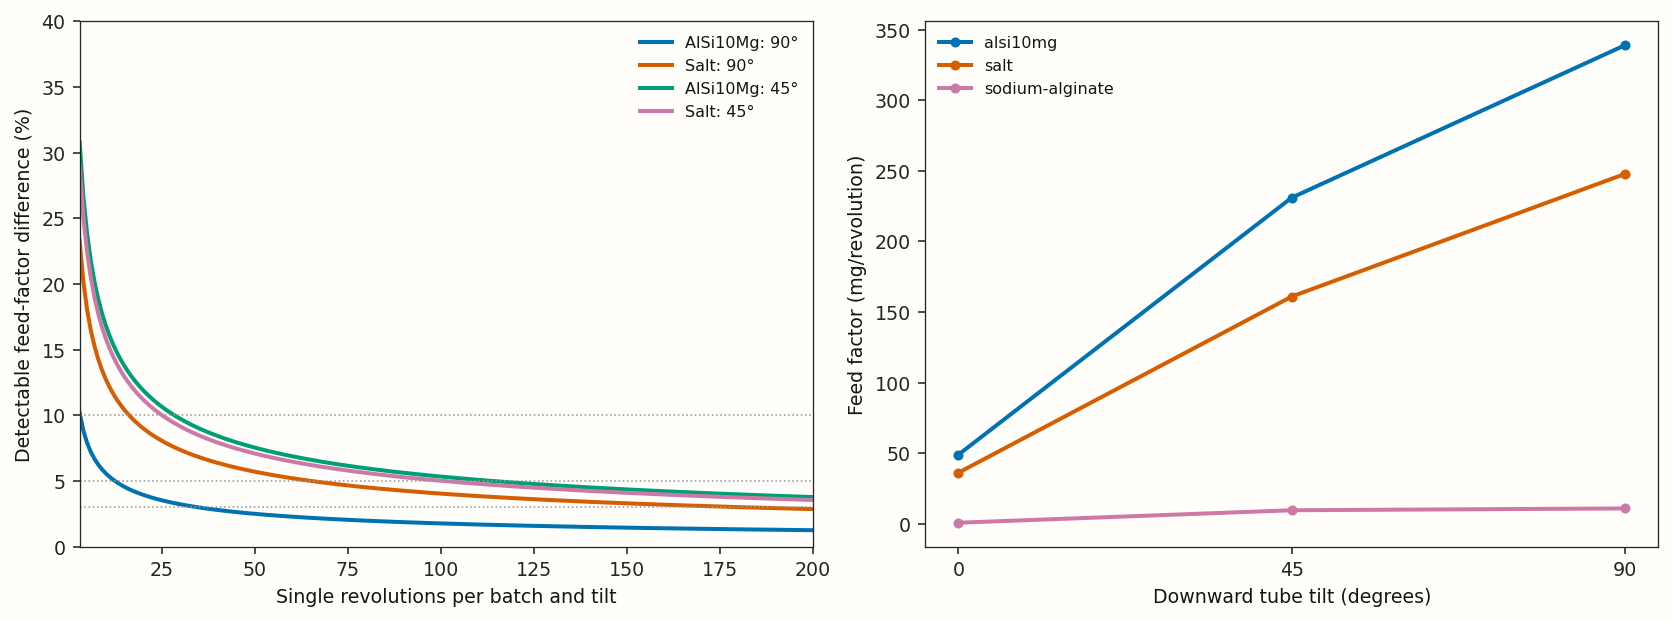

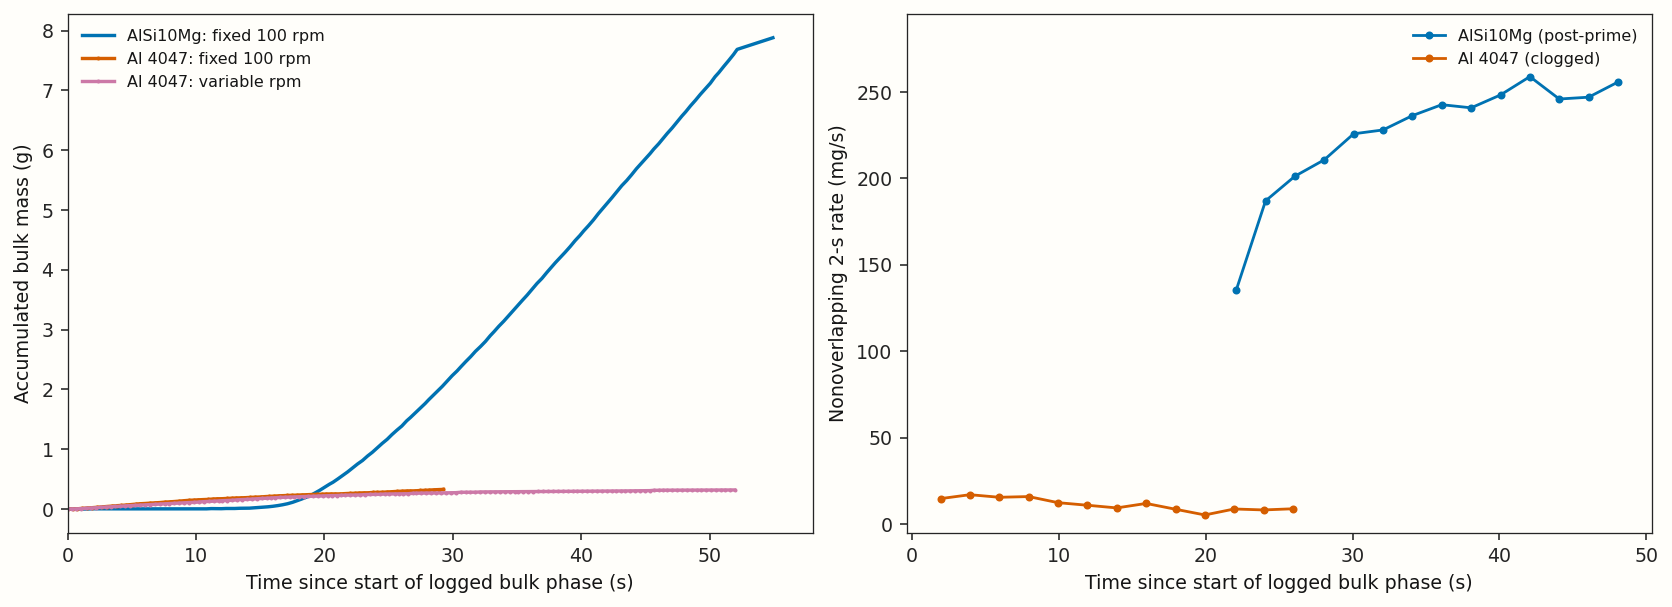

saved: [PosixPath('/workspace/analysis/production_comparison.png'), PosixPath('/workspace/analysis/resolution_and_tilt.pdf'), PosixPath('/workspace/analysis/correlations.csv'), PosixPath('/workspace/analysis/resolution_and_tilt.png'), PosixPath('/workspace/analysis/feature_table.csv'), PosixPath('/workspace/analysis/production_comparison.pdf')]


In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
# Curated E measurement: high-shock bench readouts unresolved (not negative physical tap quanta).
f.loc[['alsi10mg','silicon-110-200','sodium-sulfate'],'tap']=np.nan
f.to_csv(out/'feature_table.csv')
fig,ax=plt.subplots(1,2,figsize=(11.5,4.2),layout='constrained')
n=np.arange(3,201);k=(stats.norm.ppf(.975)+stats.norm.ppf(.8))*np.sqrt(2)
for lab,c,col in [('AlSi10Mg: 90°',.04455,'#0072B2'),('Salt: 90°',.10184,'#D55E00'),('AlSi10Mg: 45°',.13458,'#009E73'),('Salt: 45°',.12656,'#CC79A7')]:ax[0].plot(n,100*k*c/np.sqrt(n),label=lab,color=col,lw=2)
for lev in [3,5,10]:ax[0].axhline(lev,color='#999999',ls=':',lw=.8)
ax[0].set(xlabel='Single revolutions per batch and tilt',ylabel='Detectable feed-factor difference (%)',xlim=(3,200),ylim=(0,40));ax[0].legend(frameon=False,fontsize=8,loc='upper right')
for name,c,col in [('AlSi10Mg 90°',.04455,'#0072B2'),('Salt 90°',.10184,'#D55E00')]:
 q=np.array([3,6,12,24,48,96,192]);ax[1].plot(q,np.ceil((k*c/np.array([.03,.05,.10])[:,None])**2).T if False else k*c/np.sqrt(q),alpha=0) if False else None
for name,col in [('alsi10mg','#0072B2'),('salt','#D55E00'),('sodium-alginate','#CC79A7')]:
 z=f.loc[name];ax[1].plot([0,45,90],[z.ff0,z.ff45,z.ff90],marker='o',label=name,color=col,lw=2)
ax[1].set(xlabel='Downward tube tilt (degrees)',ylabel='Feed factor (mg/revolution)',xticks=[0,45,90]);ax[1].legend(frameon=False,fontsize=8)
fig.savefig(out/'resolution_and_tilt.png',dpi=250);fig.savefig(out/'resolution_and_tilt.pdf');plt.show()
fig,axes=plt.subplots(1,2,figsize=(11.5,4.1),layout='constrained')
for key,label,col in [('alsi','AlSi10Mg: fixed 100 rpm','#0072B2'),('de4dd913','Al 4047: fixed 100 rpm','#D55E00'),('56a01060','Al 4047: variable rpm','#CC79A7')]:
 a=files[key].query('phase=="bulk"');tm=a.t_s-a.t_s.min();axes[0].plot(tm,a.m_g,marker='.' if key!='alsi' else None,ms=2,lw=1.7,color=col,label=label)
axes[0].set(xlabel='Time since start of logged bulk phase (s)',ylabel='Accumulated bulk mass (g)',xlim=(0,58));axes[0].legend(frameon=False,fontsize=8,loc='upper left')
for key,label,col,lo,hi in [('alsi','AlSi10Mg (post-prime)','#0072B2',29,58),('de4dd913','Al 4047 (clogged)','#D55E00',8,35)]:
 z=files[key];b=z[z.phase=='bulk'];wr=win_rates(z,lo,hi);times=np.arange(lo,lo+2*len(wr),2)-b.t_s.min()+1
 axes[1].plot(times,wr*1000,'o-',lw=1.4,ms=3,color=col,label=label)
axes[1].set(xlabel='Time since start of logged bulk phase (s)',ylabel='Nonoverlapping 2-s rate (mg/s)',ylim=(-5,295));axes[1].legend(frameon=False,fontsize=8)
fig.savefig(out/'production_comparison.png',dpi=250);fig.savefig(out/'production_comparison.pdf');plt.show()
print('saved:',list(out.glob('*')))

In [25]:
z=files['de4dd913'];a=z[z.phase=='bulk'];wr=win_rates(z,8,35);mid=np.arange(8,8+2*len(wr),2)+1; rr=stats.linregress(mid[wr>0],np.log(wr[wr>0]));print('exploratory first 27s tau',-1/rr.slope,'r2',rr.rvalue**2,'p',rr.pvalue);print('de4 full total rate',4.17293/368.84,'end rate',json.load(open(glob.glob('/workspace/data/opt/production-al4047*/zero/trial_de4*')[0]))['stop_events'][0]['rate_slope_gps']);print('salt same 40 100 taps cv',so.query('tilt==40 and rpm==100 and tap==True').stop_rate.std()/so.query('tilt==40 and rpm==100 and tap==True').stop_rate.mean());
for key in ['alsi','de4dd913']:
 z=files[key];print('z steady',key,stats.linregress(z.query('phase=="bulk" and t_s>=30 and t_s<=58').t_s,z.query('phase=="bulk" and t_s>=30 and t_s<=58').m_g).slope if key=='alsi' else 'n/a')
print('resolution intermittent',2.802*np.sqrt(2*.13*.87/24),2.802*np.sqrt(2*.13*.87/48))

exploratory first 27s tau 27.906086637203707 r2 0.6777268666626312 p 0.0005448626915106476
de4 full total rate 0.011313659039149767 end rate 0.01488
salt same 40 100 taps cv 0.2935104615118104
z steady alsi 0.23560736919825778
z steady de4dd913 n/a
resolution intermittent 0.27202499462365587 0.1923507183506212


In [26]:
hist=list(ip.history_manager.get_range(output=False));print([(i,txt.splitlines()[0][:95]) for _,i,txt in hist][-15:])

[(15, '# Choice: exclude 08-06 salt from stable repeatability because under-filled auger (curated sour'), (16, 'def readtele(j):'), (17, 'for (run,rpm),g in list(pol.query(\'block=="D"\').groupby([\'run\',\'rpm\']))[9:12]:'), (18, 'sl=[]; ims=[]'), (19, "print(B[['powder','tilt_deg','delta_g','quality']].to_string(index=False));print(E.query('phase"), (20, "props=pd.read_csv('/workspace/data/powder-properties/literature_powder_properties.csv').set_ind"), (21, "for q in ['vol90','ff90','zero','speed','gain','cv90','prim']:"), (22, "print(glob.glob('/workspace/data/opt/production-al4047*/zero/*'));print(glob.glob('/workspace/d"), (23, 'import re'), (24, 'files={}'), (25, "a2=A[A.sigma_g.notna()]; active=a2.groupby('run').sigma_g.median();active=active[active>0].inde"), (26, 'ip=get_ipython(); hist=list(ip.history_manager.get_range(output=False));print([(i,txt.splitline'), (27, 'import matplotlib.pyplot as plt'), (28, "z=files['de4dd913'];a=z[z.phase=='bulk'];wr=win_rates(z,8,35);mid=np.a

In [27]:
h={i:txt for _,i,txt in ip.history_manager.get_range(output=False)}
selected=[3,4,10,12,15,16,18,20,24,25,27,28]
script='''"""Reproduce auger powder flowability summary. Run from /workspace with python analysis/analysis.py.
Inputs: supplied README_EDISON.md, data/battery, data/opt and powder-properties.
Outputs: analysis/*.csv, analysis/*.png, analysis/*.pdf.
All screening metrics are exploratory; no LPBF spreading outcome measurements are available.
"""\n'''+ '\n\n'.join('# --- Executed notebook block '+str(i)+' ---\n'+h[i] for i in selected)
script=script.replace("for name,c,col in [('AlSi10Mg 90°',.04455,'#0072B2'),('Salt 90°',.10184,'#D55E00')]:\n q=np.array([3,6,12,24,48,96,192]);ax[1].plot(q,np.ceil((k*c/np.array([.03,.05,.10])[:,None])**2).T if False else k*c/np.sqrt(q),alpha=0) if False else None\n",'')
(out/'analysis.py').write_text(script)
import subprocess
res=subprocess.run(['python',str(out/'analysis.py')],cwd='/workspace',env=dict(os.environ,MPLBACKEND='Agg'),capture_output=True,text=True,timeout=120)
print('script bytes',len(script),'exit',res.returncode,'stdout tail',res.stdout[-1000:],'stderr tail',res.stderr[-1000:])

script bytes 17124 exit 1 stdout tail owder_id', 'bulk_density_g_ml', 'tapped_density_g_ml', 'hausner_ratio', 'd50_um', 'angle_repose_deg', 'true_density_g_cm3', 'moisture_pct', 'hygroscopicity', 'shape', 'hr_provenance']
       powder_id  bulk_density_g_ml  tapped_density_g_ml  hausner_ratio  d50_um  angle_repose_deg  true_density_g_cm3  moisture_pct                 hygroscopicity                     shape  hr_provenance
            salt               1.19                 1.28           1.08     425                32               2.165          0.05 low (deliquesces above 75% RH)            cubic crystals     class-band
white-rice-flour               0.68                 0.80           1.18     100                45               1.450         11.70                       moderate polygonal starch granules measured-class
brown-rice-flour               0.68                 0.82           1.20     130                47               1.450         11.50                       moderate    

In [28]:
s=(out/'analysis.py').read_text();s=s.replace('# --- Executed notebook block 10 ---',"log=pd.read_csv('/workspace/docs/battery-runs/run-log.csv')\n\n# --- Executed notebook block 10 ---");(out/'analysis.py').write_text(s)
res=subprocess.run(['python',str(out/'analysis.py')],cwd='/workspace',env=dict(os.environ,MPLBACKEND='Agg'),capture_output=True,text=True,timeout=120)
print('exit',res.returncode,'stdout tail',res.stdout[-850:],'stderr tail',res.stderr[-1400:])

exit 0 stdout tail  % 54.8 revs [2002, 721, 181]
45 MDD 6rev % 21.8 revs [316, 114, 29]
90 MDD 6rev % 7.2 revs [35, 13, 4]
between day floor 90 0.39297108000000003
saved: [PosixPath('/workspace/analysis/production_comparison.png'), PosixPath('/workspace/analysis/resolution_and_tilt.pdf'), PosixPath('/workspace/analysis/analysis.py'), PosixPath('/workspace/analysis/correlations.csv'), PosixPath('/workspace/analysis/resolution_and_tilt.png'), PosixPath('/workspace/analysis/feature_table.csv'), PosixPath('/workspace/analysis/production_comparison.pdf')]
exploratory first 27s tau 27.906086637203707 r2 0.6777268666626312 p 0.0005448626915106476
de4 full total rate 0.011313659039149767 end rate 0.01488
salt same 40 100 taps cv 0.2935104615118104
z steady alsi 0.23560736919825778
z steady de4dd913 n/a
resolution intermittent 0.27202499462365587 0.1923507183506212
 stderr tail 


In [29]:
s=open('/workspace/docs/powder-battery-protocol.md').read();import re
for term in ['hopper','fill','prime','15 min','tap','tilt']:
 print('\n',term)
 print([s[m.start()-100:m.start()+160].replace('\n',' ') for m in list(re.finditer(term,s,re.I))[:4]])
print('protocol minutes',[(m.group(),m.start()) for m in re.finditer('minutes|seconds',s,re.I)][:8])


 hopper
['d `lowflow` in the CSV. The operator is only prompted after 4 consecutive low-flow rows in case the hopper is simply empty; unattended runs auto-answer `keep`.  ## Running it  ### At the bench (attended)  ```bash python scripts/powder_battery_capture.py --port', 'n rice flour, <brand/lot>" \\     --operator cr --upload ```  Answer the prompts (empty cup / refill hopper) in the same terminal: Enter to continue, `keep` to accept low flow, `skip` for next block, `abort` to end.  ### Remotely / "@claude, I\'ve loaded Brown R', 'ich runs at tilt 45° right after block C ends at 90° and so separates a tilt effect from a depleted hopper.  ### The within-run drift check (block C vs block E)  Blocks C and E measure the same quantity — mass per 360° revolution at 30 RPM — at tilts 0° and 45']

 fill
['"brown rice flour, <brand/lot>" \\     --operator cr --upload ```  Answer the prompts (empty cup / refill hopper) in the same terminal: Enter to continue, `keep` to accept low flow, `skip

In [30]:
p=Path('/workspace/.prompts/MEMORY.md');print(p.read_text());print(Path('/workspace/.prompts/USER.md').read_text())

# Project Memory

## Instructions

Edit this file (`{prompt_path}`) to persist procedural and workflow patterns specific to this project: output formats, delivery channels, and recurring conventions. Do not record scientific findings or research outputs here. Update or remove entries as the project's conventions evolve.

## Context

[Fill me in]

## Notes

[Fill me in]

# User

Edit this file (`./.prompts/USER.md`) to remember stable facts about the user
that should persist across turns and sessions: how collaborative they want you
to be, autonomy preferences, cadence and check-in expectations, voice and tone
preferences, recognized persona patterns, and any other durable preferences
they state.

Keep entries concise. One bullet per preference. Update or remove entries as
the user's preferences evolve. Do not record transient task state or scientific
findings here — use `MEMORY.md` for procedural and workflow patterns specific
to this project.


## Account

- logged-in name: Sterling G

In [31]:
for po in ['salt','alsi10mg','silicon-110-200']:
 for a in [0,45,90]:
  z=C[(C.powder==po)&(C.tilt_deg==a)&(~C.run.str.contains('20260806T145120Z'))];print(po,a,'median sigma mg',z.sigma_g.median()*1000,'median abs drift mg',z.drift_g.abs().median()*1000,'sd pooled/one',z.groupby('run').delta_g.std().mean()*1000,'shock',sum(z.shock_g.fillna(0)!=0))

salt 0 median sigma mg 1.5 median abs drift mg 3.85 sd pooled/one 6.662765476877023 shock 0
salt 45 median sigma mg 7.95 median abs drift mg 13.000000000000002 sd pooled/one 18.65104261132458 shock 0
salt 90 median sigma mg 7.45 median abs drift mg 16.3 sd pooled/one 23.341494624324746 shock 0
alsi10mg 0 median sigma mg 9.45 median abs drift mg 9.75 sd pooled/one 16.57174301836311 shock 0
alsi10mg 45 median sigma mg 13.000000000000002 median abs drift mg 11.9 sd pooled/one 31.082261822460737 shock 0
alsi10mg 90 median sigma mg 9.000000000000002 median abs drift mg 17.25 sd pooled/one 15.09935980982859 shock 1
silicon-110-200 0 median sigma mg 7.7 median abs drift mg 19.049999999999997 sd pooled/one 17.371547618639703 shock 0
silicon-110-200 45 median sigma mg 8.35 median abs drift mg 9.600000000000001 sd pooled/one 14.67678438895931 shock 0
silicon-110-200 90 median sigma mg 9.000000000000002 median abs drift mg 4.25 sd pooled/one 13.236124810532734 shock 0


In [32]:
for po in ['alsi10mg','salt']:
 for a in [45,90]:
  z=C[(C.powder==po)&(C.tilt_deg==a)&(~C.run.str.contains('20260806T145120Z'))];s=z[z.quality!='shock'];print(po,a,'all',len(z),z.delta_g.std()/z.delta_g.mean(),'drop shock',len(s),s.delta_g.std()/s.delta_g.mean())
print('min 2 sample zero setting if independent',100*(stats.norm.ppf(.975)+stats.norm.ppf(.8))*np.sqrt(2*.13*.87/24))

alsi10mg 45 all 6 0.13458437680216817 drop shock 6 0.13458437680216817
alsi10mg 90 all 6 0.04454964538698445 drop shock 5 0.027503259836862946
salt 45 all 12 0.1527709713939768 drop shock 12 0.1527709713939768
salt 90 all 12 0.12162697296408297 drop shock 12 0.12162697296408297
min 2 sample zero setting if independent 27.198472658632905


In [33]:
p=Path('/workspace/.prompts/MEMORY.md');txt=p.read_text();txt=txt.replace('## Context\n\n[Fill me in]\n\n## Notes\n\n[Fill me in]','## Context\n\n- Project workspace `/workspace` holds powder-doser battery documentation and telemetry; read `README_EDISON.md` before analyzing runs.\n\n## Notes\n\n- For quantitative reports, deliver a concise Markdown answer with extractable numeric tables and link reproducible code, CSV tables, and high-resolution figures under `/workspace/analysis/`.\n- Distinguish quality-control-valid battery A–E runs from later H/G-only runs; explain any further exclusions and show measurement limitations explicitly.')
p.write_text(txt)
report=r'''# Auger-doser screen for LPBF powder spreading

**Conclusion.** I would use a gravity-assisted *volumetric feed index* plus a low-speed *interruption fraction* as two complementary screens, paired with a same-session, sieved commercial AlSi10Mg control. Neither is a validated measure of laser powder bed fusion (LPBF) recoating. The best battery association with class-typical angle of repose (AoR) is *mass* feed factor at 90° (Spearman ρ = −0.77); density-normalization reduces this association (ρ = −0.46). Only 10 of 12 powders convey adequately, and the literature densities and AoR are not measured on these actual lots.

[Reproducible Python](analysis.py) · [all powder features](feature_table.csv) · [feature correlations](correlations.csv) · [resolution plot](resolution_and_tilt.png) · [production plot](production_comparison.png). See CSV files for exact numbers.

## 1. Measurement resolution

I analyzed 14 quality-control-valid A–E runs (252 block-C revolutions), not the later valid G/H-only runs. The 2026-08-06 salt A–E run is valid in the log, but the property curation flags an under-filled auger: I retain it as a sensitivity check, not as a normal day-to-day replicate. Fumed silica is quality-control invalid and does not supply a calibrated feature. Two valid nonconveyors (brown rice flour and silicon-325) are censored, not assigned zero feedability in correlations.

| Source / metric | Observation |
|:--|:--|
| A baseline, 4 runs with populated nonzero noise estimates | Median `sigma_g` **6.6 mg** per stable read; run baseline-difference SD **2.9–28.9 mg**; median absolute `drift_g` **5.55 mg**; **17/32** baseline actions had nonzero shock values. Earlier run baseline/noise fields are 0 or absent; do not treat those as zero noise. |
| C read quality | **2/252** flagged shocks and **60/252** unsettled final readings; successful retries do not turn every mass difference into true flow. AlSi10Mg 90° C SD is **15.1 mg**, with median within-action `sigma_g` **9 mg**; thus observed RSD includes read error and true flow variation, which these data cannot reliably partition. Dropping the one flagged 90° shock changes AlSi10Mg RSD from **4.45%** to **2.75%**. |
| C six individual turns (AlSi10Mg, 0° / 45° / 90°) | Mean **48.9 / 231.0 / 338.9 mg/rev**; observed within-run CV **33.9% / 13.5% / 4.45%**. |
| C, salt, two properly charged days | Mean **36.2 / 160.9 / 247.8 mg/rev**; pooled within-run CV **21.1% / 12.7% / 10.2%**; across-day CV of six-turn means **7.2% / 12.7% / 9.9%** (only **two** comparable days, so very uncertain). Including the underfilled third day inflates across-day CV to **68% / 75% / 75%**. |
| Continuous slope instead of single-turn differences | Block-D 3-turn mass-vs-time fits: median R² **0.982 / 0.978 / 0.899** at 15 / 45 / 90 rpm. Their slopes converted to mg/rev are only **0.78 / 0.75 / 0.59** × their corresponding endpoint mass/3 medians, because fit windows include startup/lag and only 8 polls at 90 rpm. They do not automatically give a more accurate feed factor; fit only a post-prime, fixed-speed segment, inspect residuals, and account for serially correlated polls. |
| Salt continuous production-style trials, repeated identical 40°, 100 rpm, 2 Hz taps | Nine short bulk stop-mass/time rates average **0.0376 g/s**, CV **29%**, confounded by priming, early cutoff and afterflow. Different tilt/rpm conditions must not be pooled to claim precision. |

For two independent batches measured on the **same day**, assuming stationary independent per-turn variation, equal CV \(c\), two-sided α = 0.05 and 80% power, the *optimistic normal-approximation* minimum detectable fractional difference (MDD) is \(\mathrm{MDD}(n)=[1.96+0.842]\sqrt{2}c/\sqrt n\approx3.96c/\sqrt n\). For a continuous, primed segment use effective independent revolutions, **not** number of autocorrelated polls. Systematic batch/loading effects and day effects do not average away.

| Reference CV source | 6 turns: MDD | Turns **per batch** for 3% / 5% / 10% |
|:--|--:|:--|
| AlSi10Mg 0°: 33.9% | 54.8% | 2,002 / 721 / 181 |
| AlSi10Mg 45°: 13.5% | 21.8% | 316 / 114 / 29 |
| AlSi10Mg 90°: 4.45% | **7.2%** | **35 / 13 / 4** |
| Salt 0°: 21.1% | 34.1% | 777 / 280 / 70 |
| Salt 45°: 12.7% | 20.5% | 280 / 101 / 26 |
| Salt 90°: 10.2% | **16.5%** | **181 / 66 / 17** |

A conservative estimate for **unpaired days** using the salt 90° ~9.9% between-day CV is ~39% MDD for one independent run per batch; common-day referencing may cancel some drift but is not quantified with two days. Power numbers extrapolated far beyond six revolutions are design calculations, **not demonstrated precision**.

## 2. Powder features and construct validity

Feed factors are the C means, except salt pooled over its two well-charged days. Bulk densities are literature class values. `vol90` is feed-factor mg/rev divided by bulk density g/mL, giving µL/rev. `zero` is the proportion of <2 mg *per poll* increments in a 15-rpm, 45° streamed D segment (~3 revolutions, no taps); negative balance changes also count as zero. It is a noisy, instrument-dependent operational definition. `speed` is 100×[D FF(90 rpm)/D FF(15 rpm)−1], at 45°; speed and tilt effects are not interchangeable. `tap` and spontaneous B discharge are mostly read-noise-limited; see full CSV.

| Powder | FF0 / FF45 / FF90 (mg/rev) | vol90 (µL/rev) | 90°/0° gain | Speed change (%) | D zero fraction | AoR (°) |
|:--|:--|--:|--:|--:|--:|--:|
| Salt | 36 / 161 / 248 | 208 | 6.85 | −40 | 0.26 | 32 |
| White rice flour | 3.8 / 12.8 / 37 | 55 | 9.91 | +94 | 0.89 | 45 |
| Sodium alginate | 0.8 / 9.6 / 10.9 | 20 | censored FF0 | +17 | 0.96 | 42 |
| Calcium lactate | 47 / 198 / 232 | 581 | 4.91 | −33 | 0.26 | 40 |
| Carboxymethyl cellulose | 2.6 / 26 / 9.4 | 16 | censored FF0 | +23 | 0.81 | 41 |
| Xanthan gum | 24 / 161 / 187 | 301 | 7.87 | −55 | 0.15 | 35 |
| Sodium sulfate | 51 / 208 / 244 | 174 | 4.76 | −48 | 0.19 | 32 |
| Silicon 110–200 | 57 / 211 / 302 | 242 | 5.29 | −31 | 0.19 | 36 |
| AlSi10Mg | 49 / 231 / 339 | **251** | 6.93 | −49 | **0.13** | 30 |
| Barium chloride | 23 / 185 / 200 | 154 | 8.61 | −48 | 0.19 | 34 |
| Brown rice flour; silicon-325 | **nonconveying** | censored | censored | censored | censored | 47; 43 |

The contrast of coarse silicon-110–200 and nonconveying silicon-325 shows particle-size effects can overwhelm an AoR-like summary. Fumed silica A–E failed outlet verification; do not use its apparent feed mass.

| Candidate feature vs literature | Spearman ρ vs AoR | Spearman ρ vs Hausner ratio | n |
|:--|--:|--:|--:|
| FF90 | **−0.77** | −0.50 | 10 |
| Volumetric FF90 | −0.46 | +0.05 | 10 |
| FF45 | −0.70 | −0.22 | 10 |
| FF90/FF0 (only reliably conveying at 0°) | +0.23 | +0.12 | 8 |
| Speed change 15→90 rpm | **+0.83** | +0.27 | 10 |
| 90° per-turn RSD | +0.35 | −0.13 | 10 |
| Interruption fraction | **+0.76** | +0.21 | 10 |
| Rate MAD/median | −0.57 | −0.14 | 10 |
| Priming delay in D (not a new-hopper startup) | +0.28 | +0.28 | 10 |
| 15-rpm revolution-frequency spectral share | −0.49 | −0.78 | 10 |
| Measured tap45 quantum | −0.04 | +0.08 | 10 (noisy / unresolved in metal runs) |

I prefer **90° feed plus low-speed interruption** as the two distinct readouts: FF90 versus interruption Spearman ρ = **−0.66**, whereas speed slope versus interruption is **+0.87** (more redundant). The 15-rpm spectral feature has just ~3 cycles and no spectral calibration; do not use it as a scalar. The B hold values are zero in early placeholder-filled files or shock-contaminated in later files, and tap quanta on the metal bench can even be negative: neither is a robust production screening axis. No candidate convincingly tracks Hausner ratio across this heterogeneous 10-powder set. These exploratory rank tests are not adjusted for multiple comparisons, and food/chemical powders are not an aluminium-alloy validation set.

## 3. Production trace at matched bulk settings

Both powders used 40°, 100 rpm, 2-Hz bulk taps in the comparable phase, but dose target, loading history and later stages differed. AlSi10Mg first primed for ~13 s then reached a near-steady post-prime **0.236 g/s** regression slope during 30–58 s (2-s rates, 29–58 s, mean **0.226 g/s**, CV **0.15**). The clogged Al 4047 continuation trial `de4dd913` had a bulk average **4.173 g / 368.84 s = 0.0113 g/s** (~20× less) and final estimated slope **0.0149 g/s**; its first logged 8–35 s gave **0.0113 g/s**, 2-s rate CV **0.32**. Both post-prime selected portions have zero 2-s *fully stopped* windows at a 1-mg/s threshold, so intermittency here means nonuniform reduced flow, not always complete stopping. The Al 4047 bulk-only *top-up* at variable rpm gave **0.0114 g/s** during initial 100-rpm segment and required two 3-s no-flow boosts after slowing the rpm. At 10° trickle flow stopped, and 15° taps barely discharged (the README documents ~14 mg total for 240 tap cycles plus eight nudges).

**No defensible long-time decay constant exists in the captured telemetry.** The first 4047 100-s trial (~3.49 g) lost telemetry entirely to a `MemoryError`; the 369-s continuation saves only its first ~30 s of polls, not a full mass-time trace. An exploratory exponential through those first 27 s of nonoverlapping rates gives τ ~**28 s** (log-rate R² = **0.68**), but its later 0.0149-g/s endpoint slope contradicts a single monotone exponential. I do not extrapolate τ to the powder or fit the undocumented ~0.17-g/s initial estimate. Seeing large oversize chunks lodged in the tube, degradation across sequential runs, failure at shallow tilts, and restoration after sieving/cleaning would implicate **geometric blockage** rather than innate particle cohesion; the last restoration remains to be tested. A jagged trace or zero-flow by itself cannot distinguish them.

## 4. Proposed operational protocol and flag

**Before the ~10–15-minute instrument run**, sieve to the intended LPBF upper cut and record sieve yield, oversize mass/images and a simple 2–3-pass test coupon spread; dry using an alloy-compatible validated temperature/time, cool in a sealed desiccator, record humidity and actual poured bulk density. Oven drying cannot honestly be completed within 15 minutes. Check outlet, clean flights, fix powder fill mass at **30 g if hopper capacity permits** (otherwise choose one standardized fill height), run control and unknown at the *same* fill and environment. Never regard an obstructed or unprimed auger as a negative flowability value.

1. Use 8 baseline stable reads; reject/repair if shock or baseline difference SD >**10 mg** (provisional acceptance threshold, below the 20–30-mg noisy-bench regime). Check 15-s static hold at 90° for uncontrolled discharge. Hand-prime at 45°/30 rpm until a fixed-speed continuous slope over 3 revolutions stabilizes (<10% change between adjacent 3-turn blocks); log turns-to-prime. If it takes >30 turns or stalls, report `no conveyance / mechanical inspection`, not zero FF.
2. With **taps off**, two consecutive six-turn sets at 45° and at 90°, 30 rpm, recording settled mass per turn and read flags. Optional 3 turns at 0° for diagnosing gravity gain (not for high-precision batch rejection); record tilt order and refill state. Run **6 continuous revolutions** at 45°/15 rpm with streamed polls and fixed sensor geometry; analyze after a stable prime. Do not infer an auger revolution spectral peak from 90-rpm data at 2.5–4 Hz polling (Nyquist limit). No routine tapping: 2-Hz taps have their own powder-specific transport effect; optionally use 4 individually paired re-feed/tap trials at 45° only as a diagnostic, not a scalar screen.
3. Repeat after **one independent refill/reprime** if the time budget allows; report both run values rather than pooling polls. In the same session run the sieved commercial **AlSi10Mg** through the same steps (can be a short reference panel if it already has a same-day baseline); reference run takes additional bench time. Record 6-turn FF and zero fraction per segment plus shock count, density, elapsed time and oversize retained by the sieve. A full A–E battery already takes ~13–15 min *without* extra refills; the proposed abbreviated procedure avoids the 16-tap block to stay within ~15 min per sample, excluding offline conditioning and the separately timed control.

Two *flow-oriented* scalar readouts, with reference normalization to account for geometry, are:

\[
V_g=\frac{\widehat{FF}_{90}/\rho_{b,\mathrm{lot}}}{\widehat{FF}_{90,R}/\rho_{b,R}},\qquad
I_\mathrm{stop}=\frac{1}{N}\sum_{i=1}^N \mathbf 1\!\left[\Delta m_i < \max\{2\,{\rm mg},3\,\sigma_{\Delta m}\}\right], \quad (45^\circ,15\,\mathrm{rpm};\ \mathrm{no\ taps}).
\]

Here \(V_g\) is a unitless **gravity-assisted volumetric flow index**, while \(I_\mathrm{stop}\) is a unitless **dynamic intermittent/cohesion proxy**, analogous in purpose, *not physics or calibration*, to a rotating-drum cohesive index. \(\sigma_{\Delta m}\) is a quiet-balance noise estimate for a poll-to-poll mass difference, measured with the motor off in the same session; the historical 2-mg poll cutoff was a retrospective convention, not a universal threshold. Normalize the interruption as \(\Delta I=I_\mathrm{stop,batch}-I_\mathrm{stop,R}\), and keep a rate-MAD and prime-delay as diagnostic axes. Using lot bulk density makes \(V_g\) sensitive to how that density was prepared; do not rely on literature density for numerical acceptance.

**Expected single-run resolution:** at 90°, six-turn FF is ~**7% MDD** on this one AlSi10Mg run and ~**17%** on the two salt days, conditional on equal, independent turn CV; ratio to an independently measured reference adds its variance as in the MDD equation. The interruption index lacks real same-day repeats at fixed conditions: with 6 turns at 15 rpm (~24 independent 1-s windows *at best*), reference \(p\approx0.13\) gives an optimistic MDD ~**0.27 absolute fraction**; serial correlation and noise can only worsen it. The measured salt interrupted fraction changed **0.32 to 0.19** across its two normal days. A slope over many genuinely steady, independently effective turns can improve FF sampling error, but not the between-day/load floor.

**Provisional flag:** hold a batch for particle-size/sieve and instrument inspection if \(V_g<0.8\), or \(\Delta I>0.30\), or the line stops conveying/requires >30 prime turns. A result within ±20% in \(V_g\) and ±0.30 in interruption is **indeterminate**, not certified recoatable. Repeat same-day against the control before rejecting; prioritize sieve/chunk checks for abrupt clogging and failure at shallow angles, but check fines, agglomeration and spread-coupon layer density for persistently poor flow after sieving. Recalibrate these thresholds against *measured* thin-layer packing, roller/blade streaks and LPBF coupon outcomes across future sieved Al-alloy lots. The auger shears at low consolidation rather than squeezing a thin layer under a recoater: it can flag auger jamming and low/intermittent throughput, but **cannot guarantee** detection of oversize blade streaking (especially if a few chunks bypass the auger), low layer density from fines/cohesion, surface electrostatics, or recoater-smearing/agglomerates. Sieving and direct spread tests remain required.

### Discretionary analytical decisions
- I used only quality-control-valid A–E trials, excluded the documented under-filled salt run from stable repeatability, and treated nonconveying/invalid outlets as censored rather than zero-valued material responses.
- I computed CV on six single-turn mass differences without pretending the measured balance noise can be subtracted exactly; I treated bulk stop-rate variability as a warning, not independent turn-level precision.
- I chose 90° feed for its repeatability and interruption fraction for a distinct low-speed failure mode; the normalized volumetric form is operationally useful but has weaker AoR correlation than raw mass feed.
- I used normal power formulas only for conditional planning, and refused a production long-time decay constant because the crucial telemetry is absent.
'''
report=report.replace('\x7f','')
(out/'report.md').write_text(report)
print('report chars',len(report),'exists', (out/'report.md').exists())

report chars 16101 exists True


In [34]:
p=out/'report.md';s=p.read_text();s=s.replace('ρ = −0.77','ρ = −0.77').replace('| Measured tap45 quantum | −0.04 | +0.08 | 10 (noisy / unresolved in metal runs) |','| Measured tap45 quantum | ~−0.04 | ~+0.08 | 10 raw trials (3 metal powders unresolved; exploratory only) |')
p.write_text(s)
print('verifications',s[:450],s[-550:]);print('saved sizes',[(x.name,round(x.stat().st_size/1024)) for x in out.glob('*')])

verifications # Auger-doser screen for LPBF powder spreading

**Conclusion.** I would use a gravity-assisted *volumetric feed index* plus a low-speed *interruption fraction* as two complementary screens, paired with a same-session, sieved commercial AlSi10Mg control. Neither is a validated measure of laser powder bed fusion (LPBF) recoating. The best battery association with class-typical angle of repose (AoR) is *mass* feed factor at 90° (Spearman ρ = −0.77); -turn mass differences without pretending the measured balance noise can be subtracted exactly; I treated bulk stop-rate variability as a warning, not independent turn-level precision.
- I chose 90° feed for its repeatability and interruption fraction for a distinct low-speed failure mode; the normalized volumetric form is operationally useful but has weaker AoR correlation than raw mass feed.
- I used normal power formulas only for conditional planning, and refused a production long-time decay constant because the crucial teleme

In [35]:
s=(out/'report.md').read_text();print(repr(s[s.index('For two independent'):s.index('For two independent')+400]));print(repr(s[s.index('Two *flow-oriented*'):s.index('Two *flow-oriented*')+450]))

'For two independent batches measured on the **same day**, assuming stationary independent per-turn variation, equal CV \\(c\\), two-sided α = 0.05 and 80% power, the *optimistic normal-approximation* minimum detectable fractional difference (MDD) is \\(\\mathrm{MDD}(n)=[1.96+0.842]\\sqrt{2}c/\\sqrt n\\approx3.96c/\\sqrt n\\). For a continuous, primed segment use effective independent revolutions, **not** n'
'Two *flow-oriented* scalar readouts, with reference normalization to account for geometry, are:\n\n\\[\nV_g=\\frac{\\widehat{FF}_{90}/\\rho_{b,\\mathrm{lot}}}{\\widehat{FF}_{90,R}/\\rho_{b,R}},\\qquad\nI_\\mathrm{stop}=\\frac{1}{N}\\sum_{i=1}^N \\mathbf 1\\!\\left[\\Delta m_i < \\max\\{2\\,{\\rm mg},3\\,\\sigma_{\\Delta m}\\}\\right], \\quad (45^\\circ,15\\,\\mathrm{rpm};\\ \\mathrm{no\\ taps}).\n\\]\n\nHere \\(V_g\\) is a unitless **gravity-assisted volumetric flow index**, while \\(I_\\'
